# Architectures for Diffusion Models
**Lecture — Politecnico di Milano**

The diffusion forward/reverse process is **architecture-agnostic**: any neural network $\boldsymbol{\varepsilon}_\theta(\mathbf{x}_t, t)$ that takes a noisy tensor and a timestep and returns a tensor of the same shape can be used.

In practice, four families dominate:

| Architecture | Inductive bias | Best for | Key paper |
|---|---|---|---|
| **2D U-Net** | Local spatial structure | Images | DDPM (2020) |
| **U-Net + Attention** | Local + global context | High-res images | Improved DDPM (2021) |
| **1D U-Net** | Local temporal structure | Sequences, trajectories | Diffusion Policy (2023) |
| **Transformer (DiT)** | Long-range, permutation-equiv. | Images, video, text | DiT (2022) |

In [1]:
import math, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


---
## Shared Building Blocks

All architectures share these components:

### Sinusoidal Time Embedding
Timestep $t \in \{0,\ldots,T\}$ is encoded with sinusoidal frequencies (like positional encoding in Transformers):
$$\text{PE}(t)_{2k} = \sin\!\left(\frac{t}{10000^{2k/d}}\right), \quad \text{PE}(t)_{2k+1} = \cos\!\left(\frac{t}{10000^{2k/d}}\right)$$

This embedding is then passed through an MLP and **injected into every block** via AdaGN (adaptive group normalization):
$$\text{AdaGN}(\mathbf{h}, \mathbf{t}) = \mathbf{t}_s \cdot \text{GroupNorm}(\mathbf{h}) + \mathbf{t}_b$$

In [2]:
# ── Shared primitives used across all architectures ──────────────────────────

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        x = t[:, None].float() * freqs[None, :]
        return torch.cat([x.sin(), x.cos()], dim=-1)

class TimeEmbedMLP(nn.Module):
    def __init__(self, base_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            SinusoidalEmbedding(base_dim),
            nn.Linear(base_dim, out_dim), nn.GELU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward(self, t): return self.net(t)

class AdaGN(nn.Module):
    """Adaptive GroupNorm: conditions activations on a time embedding."""
    def __init__(self, ch, t_dim, n_groups=8):
        super().__init__()
        self.norm      = nn.GroupNorm(min(n_groups, ch), ch)
        self.scale_mlp = nn.Sequential(nn.SiLU(), nn.Linear(t_dim, ch * 2))
    def forward(self, x, t_emb):
        # x: (B, C, *spatial),  t_emb: (B, t_dim)
        scale_shift = self.scale_mlp(t_emb)    # (B, 2C)
        ndim = x.ndim - 2
        scale_shift = scale_shift.view(*scale_shift.shape, *([1]*ndim))
        scale, shift = scale_shift.chunk(2, dim=1)
        return self.norm(x) * (1 + scale) + shift

print('Shared primitives ready.')

Shared primitives ready.


---
## 1. Standard 2D U-Net

The original DDPM architecture. Key properties:
- **Encoder–decoder** with MaxPool downsampling and ConvTranspose upsampling
- **Skip connections** preserve fine-grained spatial details
- **3 resolutions**: 28→14→7 (for 28×28 input)
- Self-attention **only at the bottleneck** (7×7)

```
(1,28,28) → [ResBlk] → [Pool] → [ResBlk] → [Pool] → [ResBlk+Attn] → ... → (1,28,28)
     ↑_______skip1_________________skip2______________________________________↑
```

In [3]:
class ResBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, dropout=0.1):
        super().__init__()
        self.ada1  = AdaGN(in_ch, t_dim)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.ada2  = AdaGN(out_ch, t_dim)
        self.drop  = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.res   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act   = nn.SiLU()
    def forward(self, x, t):
        h = self.conv1(self.act(self.ada1(x, t)))
        h = self.conv2(self.drop(self.act(self.ada2(h, t))))
        return h + self.res(x)

class SelfAttn2D(nn.Module):
    def __init__(self, ch, heads=4):
        super().__init__()
        self.norm  = nn.GroupNorm(min(8, ch), ch)
        self.qkv   = nn.Conv1d(ch, ch*3, 1)
        self.proj  = nn.Conv1d(ch, ch, 1)
        self.heads = heads
        self.scale = (ch // heads) ** -0.5
    def forward(self, x):
        B, C, H, W = x.shape
        h   = self.norm(x).reshape(B, C, H*W)
        qkv = self.qkv(h).reshape(B, 3, self.heads, C//self.heads, H*W)
        q, k, v = qkv.unbind(1)
        a   = torch.softmax(torch.einsum('bhdi,bhdj->bhij', q, k) * self.scale, dim=-1)
        out = torch.einsum('bhij,bhdj->bhdi', a, v).reshape(B, C, H*W)
        return self.proj(out).reshape(B, C, H, W) + x

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, dim=64, t_dim=256):
        super().__init__()
        d, d2, d4 = dim, dim*2, dim*4
        self.time  = TimeEmbedMLP(dim, t_dim)
        self.inc   = nn.Conv2d(in_ch, d, 3, padding=1)
        # Encoder
        self.e1    = ResBlock2D(d,  d,  t_dim);  self.p1 = nn.MaxPool2d(2)
        self.e2    = ResBlock2D(d,  d2, t_dim);  self.p2 = nn.MaxPool2d(2)
        self.e3    = ResBlock2D(d2, d4, t_dim)
        # Bottleneck with attention
        self.mid1  = ResBlock2D(d4, d4, t_dim)
        self.attn  = SelfAttn2D(d4)
        self.mid2  = ResBlock2D(d4, d4, t_dim)
        # Decoder
        self.u3  = nn.ConvTranspose2d(d4, d4, 2, stride=2)
        self.d3  = ResBlock2D(d4+d2, d2, t_dim)
        self.u2  = nn.ConvTranspose2d(d2, d2, 2, stride=2)
        self.d2  = ResBlock2D(d2+d,  d,  t_dim)
        self.d1  = ResBlock2D(d+d,   d,  t_dim)
        self.out = nn.Sequential(nn.GroupNorm(min(8,d), d), nn.SiLU(), nn.Conv2d(d, in_ch, 1))
    def forward(self, x, t):
        te = self.time(t)
        x0 = self.inc(x)
        x1 = self.e1(x0, te);  x2 = self.e2(self.p1(x1), te);  x3 = self.e3(self.p2(x2), te)
        x3 = self.mid2(self.attn(self.mid1(x3, te)), te)
        h  = self.d3(torch.cat([self.u3(x3), x2], 1), te)
        h  = self.d2(torch.cat([self.u2(h),  x1], 1), te)
        h  = self.d1(torch.cat([h,            x0], 1), te)
        return self.out(h)

m = UNet2D(in_ch=1, dim=64).to(DEVICE)
x_test = torch.randn(2, 1, 28, 28, device=DEVICE)
t_test = torch.randint(0, 1000, (2,), device=DEVICE)
print(f'UNet2D  input: {tuple(x_test.shape)} → output: {tuple(m(x_test, t_test).shape)}')
print(f'UNet2D  params: {sum(p.numel() for p in m.parameters()):,}')

UNet2D  input: (2, 1, 28, 28) → output: (2, 1, 28, 28)
UNet2D  params: 6,562,497


---
## 2. U-Net with Multi-Scale Attention

Improvement from Nichol & Dhariwal (2021): add self-attention **at every resolution**, not just the bottleneck.
This captures both local (high-res) and global (low-res) structure.

| Resolution | DDPM | Improved DDPM |
|---|---|---|
| 28×28 | ResBlk only | ResBlk + Attn |
| 14×14 | ResBlk only | ResBlk + Attn |
| 7×7 (bottleneck) | ResBlk + Attn | ResBlk + Attn |

In [4]:
class ResAttnBlock2D(nn.Module):
    """Residual block followed by optional self-attention."""
    def __init__(self, in_ch, out_ch, t_dim, use_attn=True):
        super().__init__()
        self.res  = ResBlock2D(in_ch, out_ch, t_dim)
        self.attn = SelfAttn2D(out_ch) if use_attn else nn.Identity()
    def forward(self, x, t):
        return self.attn(self.res(x, t))

class UNet2DAttentionFull(nn.Module):
    """U-Net with self-attention at every resolution level."""
    def __init__(self, in_ch=1, dim=64, t_dim=256):
        super().__init__()
        d, d2, d4 = dim, dim*2, dim*4
        self.time  = TimeEmbedMLP(dim, t_dim)
        self.inc   = nn.Conv2d(in_ch, d, 3, padding=1)
        self.e1    = ResAttnBlock2D(d,  d,  t_dim, use_attn=True)
        self.p1    = nn.MaxPool2d(2)
        self.e2    = ResAttnBlock2D(d,  d2, t_dim, use_attn=True)
        self.p2    = nn.MaxPool2d(2)
        self.e3    = ResAttnBlock2D(d2, d4, t_dim, use_attn=True)
        self.mid1  = ResBlock2D(d4, d4, t_dim)
        self.attn  = SelfAttn2D(d4)
        self.mid2  = ResBlock2D(d4, d4, t_dim)
        self.u3    = nn.ConvTranspose2d(d4, d4, 2, stride=2)
        self.d3    = ResAttnBlock2D(d4+d2, d2, t_dim, use_attn=True)
        self.u2    = nn.ConvTranspose2d(d2, d2, 2, stride=2)
        self.d2    = ResAttnBlock2D(d2+d,  d,  t_dim, use_attn=True)
        self.d1    = ResAttnBlock2D(d+d,   d,  t_dim, use_attn=True)
        self.out   = nn.Sequential(nn.GroupNorm(min(8,d), d), nn.SiLU(), nn.Conv2d(d, in_ch, 1))
    def forward(self, x, t):
        te = self.time(t)
        x0 = self.inc(x)
        x1 = self.e1(x0, te);  x2 = self.e2(self.p1(x1), te);  x3 = self.e3(self.p2(x2), te)
        x3 = self.mid2(self.attn(self.mid1(x3, te)), te)
        h  = self.d3(torch.cat([self.u3(x3), x2], 1), te)
        h  = self.d2(torch.cat([self.u2(h),  x1], 1), te)
        h  = self.d1(torch.cat([h,            x0], 1), te)
        return self.out(h)

m2 = UNet2DAttentionFull(in_ch=1, dim=64).to(DEVICE)
print(f'UNet2D+Attn  input: {tuple(x_test.shape)} → output: {tuple(m2(x_test, t_test).shape)}')
print(f'UNet2D+Attn  params: {sum(p.numel() for p in m2.parameters()):,}')

UNet2D+Attn  input: (2, 1, 28, 28) → output: (2, 1, 28, 28)
UNet2D+Attn  params: 7,009,089


---
## 3. 1D U-Net for Sequences (Trajectories)

For **robot trajectories**, audio, and other 1D signals, we replace all 2D convolutions with **1D convolutions**.
Input shape: `(B, D, T_horizon)` — batch × feature dim × sequence length.

This is the backbone used by **Diffusion Policy** (Chi et al. 2023).

In [5]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, kernel=5, dropout=0.1):
        super().__init__()
        pad = kernel // 2
        self.ada1  = AdaGN(in_ch, t_dim, n_groups=min(8, in_ch))
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, padding=pad)
        self.ada2  = AdaGN(out_ch, t_dim, n_groups=min(8, out_ch))
        self.drop  = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, padding=pad)
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act   = nn.SiLU()
    def forward(self, x, t):
        h = self.conv1(self.act(self.ada1(x, t)))
        h = self.conv2(self.drop(self.act(self.ada2(h, t))))
        return h + self.res(x)

class UNet1D(nn.Module):
    """1D U-Net for denoising trajectory sequences.
    Input: (B, D_action, T_horizon)
    Output: (B, D_action, T_horizon)  — predicted noise
    """
    def __init__(self, in_ch=2, dim=64, t_dim=256):
        super().__init__()
        d, d2, d4 = dim, dim*2, dim*4
        self.time  = TimeEmbedMLP(dim, t_dim)
        self.inc   = nn.Conv1d(in_ch, d, 3, padding=1)
        self.e1    = ResBlock1D(d,  d,  t_dim);  self.p1 = nn.MaxPool1d(2)
        self.e2    = ResBlock1D(d,  d2, t_dim);  self.p2 = nn.MaxPool1d(2)
        self.e3    = ResBlock1D(d2, d4, t_dim)
        self.mid1  = ResBlock1D(d4, d4, t_dim)
        self.mid2  = ResBlock1D(d4, d4, t_dim)
        self.u3    = nn.ConvTranspose1d(d4, d4, 2, stride=2)
        self.d3    = ResBlock1D(d4+d2, d2, t_dim)
        self.u2    = nn.ConvTranspose1d(d2, d2, 2, stride=2)
        self.d2    = ResBlock1D(d2+d,  d,  t_dim)
        self.d1    = ResBlock1D(d+d,   d,  t_dim)
        self.out   = nn.Sequential(nn.GroupNorm(min(8,d), d), nn.SiLU(), nn.Conv1d(d, in_ch, 1))
    def forward(self, x, t):
        # x: (B, D_action, T_horizon)
        te = self.time(t)
        x0 = self.inc(x)
        x1 = self.e1(x0, te);  x2 = self.e2(self.p1(x1), te);  x3 = self.e3(self.p2(x2), te)
        x3 = self.mid2(self.mid1(x3, te), te)
        h  = self.d3(torch.cat([self.u3(x3), x2], 1), te)
        h  = self.d2(torch.cat([self.u2(h),  x1], 1), te)
        h  = self.d1(torch.cat([h,            x0], 1), te)
        return self.out(h)

D_ACTION = 2; T_HORIZON = 16
m3 = UNet1D(in_ch=D_ACTION, dim=64).to(DEVICE)
x_seq = torch.randn(2, D_ACTION, T_HORIZON, device=DEVICE)
print(f'UNet1D  input: {tuple(x_seq.shape)} → output: {tuple(m3(x_seq, t_test).shape)}')
print(f'UNet1D  params: {sum(p.numel() for p in m3.parameters()):,}')

UNet1D  input: (2, 2, 16) → output: (2, 2, 16)
UNet1D  params: 4,185,154


---
## 4. Transformer (DiT — Diffusion Transformer)

Peebles & Xie (2022) replaced the U-Net with a **pure Transformer** operating on image patches.

**Pipeline:**
1. Patchify: split $(C, H, W)$ image into $N = (H/p)\times(W/p)$ patches of size $p\times p$
2. Linear projection: each patch → token of dim $d$
3. Add 2D positional embedding
4. Process through $L$ Transformer blocks with **AdaLayerNorm** time conditioning
5. Unpatchify: tokens → noise prediction

AdaLayerNorm: $\text{AdaLN}(\mathbf{h}, \mathbf{t}) = \text{scale}(\mathbf{t}) \cdot \text{LayerNorm}(\mathbf{h}) + \text{shift}(\mathbf{t})$

**Advantage over U-Net:** No inductive locality bias — the model can attend globally from layer 1.

In [6]:
class AdaLayerNorm(nn.Module):
    """Adaptive LayerNorm for time conditioning (DiT-style)."""
    def __init__(self, d_model, t_dim):
        super().__init__()
        self.norm = nn.LayerNorm(d_model, elementwise_affine=False)
        self.mlp  = nn.Sequential(nn.SiLU(), nn.Linear(t_dim, d_model * 2))
    def forward(self, x, t_emb):
        # x: (B, N, d),  t_emb: (B, t_dim)
        scale_shift = self.mlp(t_emb).unsqueeze(1)   # (B, 1, 2d)
        scale, shift = scale_shift.chunk(2, dim=-1)
        return self.norm(x) * (1 + scale) + shift

class DiTBlock(nn.Module):
    def __init__(self, d_model, n_heads, t_dim, mlp_ratio=4):
        super().__init__()
        self.norm1 = AdaLayerNorm(d_model, t_dim)
        self.attn  = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm2 = AdaLayerNorm(d_model, t_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(d_model, d_model * mlp_ratio), nn.GELU(),
            nn.Linear(d_model * mlp_ratio, d_model)
        )
    def forward(self, x, t_emb):
        h = self.norm1(x, t_emb)
        x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.mlp(self.norm2(x, t_emb))
        return x

class DiT(nn.Module):
    """Diffusion Transformer (simplified).
    Input : (B, C, H, W) noisy image + (B,) timestep
    Output: (B, C, H, W) predicted noise
    """
    def __init__(self, in_ch=1, img_size=28, patch_size=4, d_model=256, n_heads=8, depth=6, t_dim=256):
        super().__init__()
        assert img_size % patch_size == 0
        self.patch_size = patch_size
        self.n_patches  = (img_size // patch_size) ** 2
        patch_dim       = in_ch * patch_size * patch_size

        self.time       = TimeEmbedMLP(d_model, t_dim)
        self.patch_emb  = nn.Linear(patch_dim, d_model)
        self.pos_emb    = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)
        self.blocks     = nn.ModuleList([DiTBlock(d_model, n_heads, t_dim) for _ in range(depth)])
        self.norm_out   = nn.LayerNorm(d_model)
        self.unpatch    = nn.Linear(d_model, patch_dim)

        self.in_ch      = in_ch
        self.img_size   = img_size

    def patchify(self, x):
        B, C, H, W = x.shape
        p  = self.patch_size
        nH = H // p; nW = W // p
        x  = x.reshape(B, C, nH, p, nW, p).permute(0, 2, 4, 1, 3, 5)
        return x.reshape(B, nH * nW, C * p * p)     # (B, N, patch_dim)

    def unpatchify(self, tokens):
        B, N, _ = tokens.shape
        p  = self.patch_size
        nH = nW = int(N ** 0.5)
        x  = tokens.reshape(B, nH, nW, self.in_ch, p, p)
        x  = x.permute(0, 3, 1, 4, 2, 5).reshape(B, self.in_ch, nH*p, nW*p)
        return x

    def forward(self, x, t):
        te     = self.time(t)
        tokens = self.patch_emb(self.patchify(x)) + self.pos_emb
        for blk in self.blocks:
            tokens = blk(tokens, te)
        tokens = self.unpatch(self.norm_out(tokens))
        return self.unpatchify(tokens)

m4 = DiT(in_ch=1, img_size=28, patch_size=4, d_model=256, depth=6).to(DEVICE)
print(f'DiT  input: {tuple(x_test.shape)} → output: {tuple(m4(x_test, t_test).shape)}')
print(f'DiT  params: {sum(p.numel() for p in m4.parameters()):,}')

DiT  input: (2, 1, 28, 28) → output: (2, 1, 28, 28)
DiT  params: 6,464,528


---
## 5. Architecture Comparison

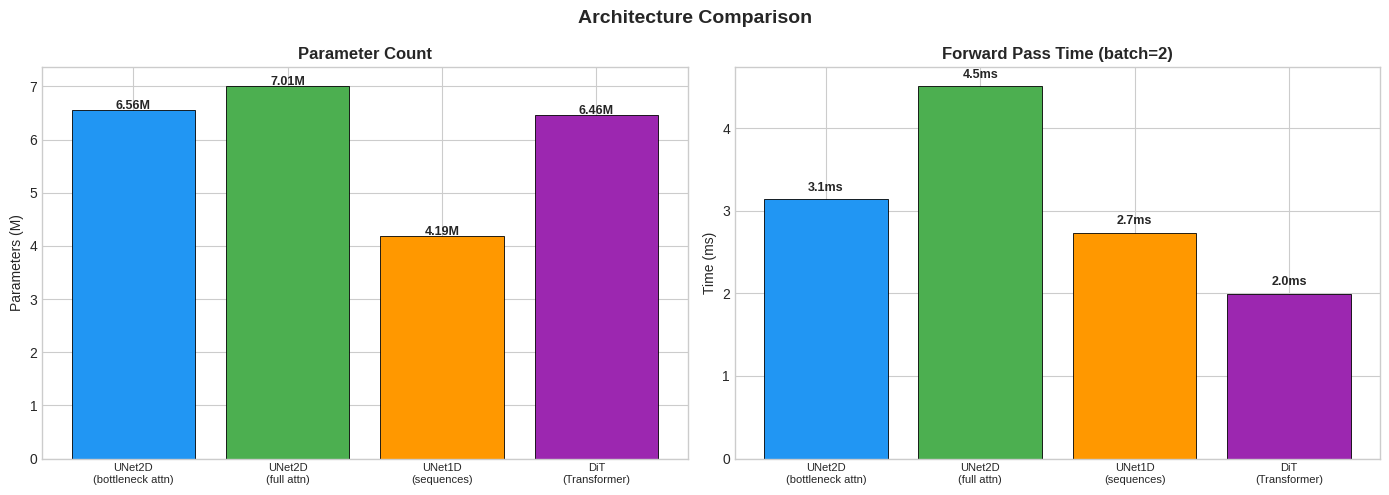

In [7]:
import time

models = {
    'UNet2D\n(bottleneck attn)':   (m,  x_test, t_test),
    'UNet2D\n(full attn)':         (m2, x_test, t_test),
    'UNet1D\n(sequences)':         (m3, x_seq,  t_test),
    'DiT\n(Transformer)':          (m4, x_test, t_test),
}

params, fwd_ms = {}, {}
for name, (model, x_in, t_in) in models.items():
    params[name] = sum(p.numel() for p in model.parameters())
    # Warmup
    with torch.no_grad():
        for _ in range(3): _ = model(x_in, t_in)
    # Measure
    torch.cuda.synchronize() if DEVICE=='cuda' else None
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(20): _ = model(x_in, t_in)
    torch.cuda.synchronize() if DEVICE=='cuda' else None
    fwd_ms[name] = (time.perf_counter() - t0) / 20 * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(params.keys())
cols  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars1 = axes[0].bar(names, [params[n]/1e6 for n in names], color=cols, edgecolor='black', linewidth=0.6)
for b, n in zip(bars1, names):
    axes[0].text(b.get_x()+b.get_width()/2., b.get_height()+0.02,
                 f'{params[n]/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Parameter Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Parameters (M)')
axes[0].tick_params(axis='x', labelsize=8)

bars2 = axes[1].bar(names, [fwd_ms[n] for n in names], color=cols, edgecolor='black', linewidth=0.6)
for b, n in zip(bars2, names):
    axes[1].text(b.get_x()+b.get_width()/2., b.get_height()+0.1,
                 f'{fwd_ms[n]:.1f}ms', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Forward Pass Time (batch=2)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Time (ms)')
axes[1].tick_params(axis='x', labelsize=8)

plt.suptitle('Architecture Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

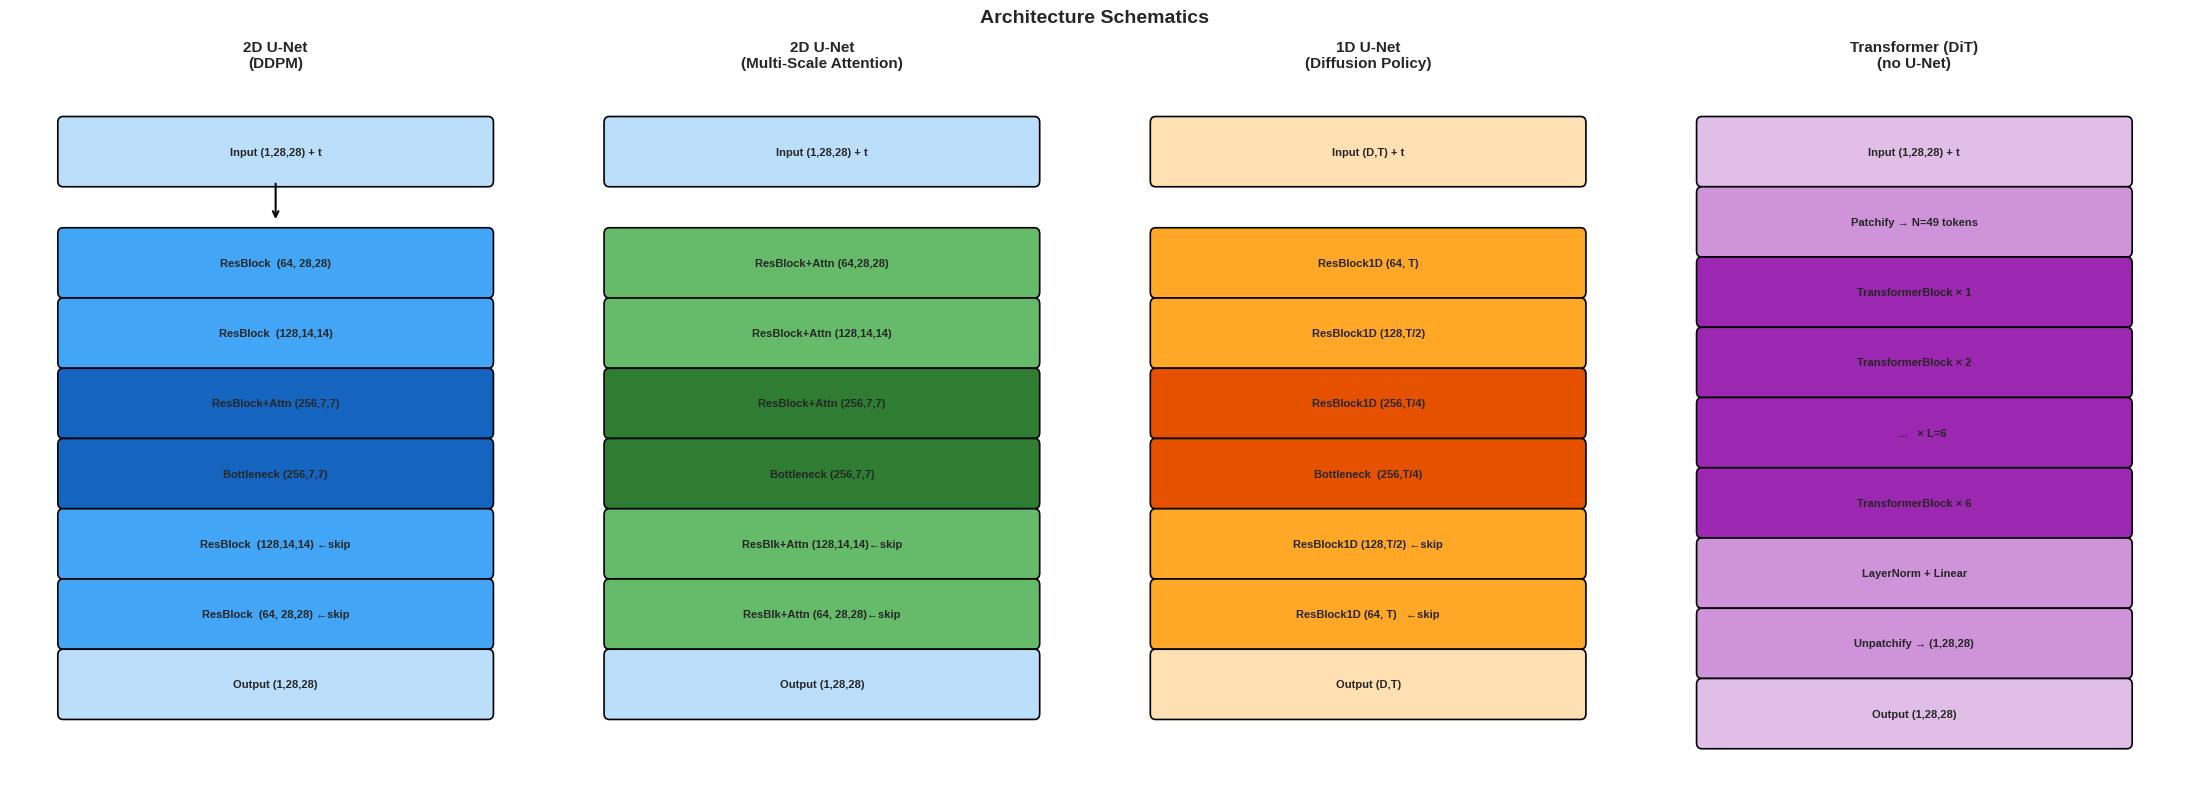

In [8]:
# ── Architecture diagram (schematic) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 8))
for ax in axes: ax.set_xlim(0, 10); ax.set_ylim(0, 12); ax.axis('off')

def draw_box(ax, x, y, w, h, color, label, fontsize=8):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                          facecolor=color, edgecolor='black', linewidth=1.2))
    ax.text(x+w/2, y+h/2, label, ha='center', va='center', fontsize=fontsize, fontweight='bold')

def draw_arrow(ax, x, y1, y2):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# UNet2D
ax = axes[0]
draw_box(ax, 1, 10.2, 8, 1.0, '#BBDEFB', 'Input (1,28,28) + t')
draw_arrow(ax, 5, 10.2, 9.5)
draw_box(ax, 1, 8.3, 8, 1.0, '#42A5F5', 'ResBlock  (64, 28,28)')
draw_box(ax, 1, 7.1, 8, 1.0, '#42A5F5', 'ResBlock  (128,14,14)')
draw_box(ax, 1, 5.9, 8, 1.0, '#1565C0', 'ResBlock+Attn (256,7,7)')
draw_box(ax, 1, 4.7, 8, 1.0, '#1565C0', 'Bottleneck (256,7,7)')
draw_box(ax, 1, 3.5, 8, 1.0, '#42A5F5', 'ResBlock  (128,14,14) ←skip')
draw_box(ax, 1, 2.3, 8, 1.0, '#42A5F5', 'ResBlock  (64, 28,28) ←skip')
draw_box(ax, 1, 1.1, 8, 1.0, '#BBDEFB', 'Output (1,28,28)')
ax.set_title('2D U-Net\n(DDPM)', fontsize=11, fontweight='bold')

# UNet2D+Attn
ax = axes[1]
draw_box(ax, 1, 10.2, 8, 1.0, '#BBDEFB', 'Input (1,28,28) + t')
draw_box(ax, 1, 8.3, 8, 1.0, '#66BB6A', 'ResBlock+Attn (64,28,28)')
draw_box(ax, 1, 7.1, 8, 1.0, '#66BB6A', 'ResBlock+Attn (128,14,14)')
draw_box(ax, 1, 5.9, 8, 1.0, '#2E7D32', 'ResBlock+Attn (256,7,7)')
draw_box(ax, 1, 4.7, 8, 1.0, '#2E7D32', 'Bottleneck (256,7,7)')
draw_box(ax, 1, 3.5, 8, 1.0, '#66BB6A', 'ResBlk+Attn (128,14,14)←skip')
draw_box(ax, 1, 2.3, 8, 1.0, '#66BB6A', 'ResBlk+Attn (64, 28,28)←skip')
draw_box(ax, 1, 1.1, 8, 1.0, '#BBDEFB', 'Output (1,28,28)')
ax.set_title('2D U-Net\n(Multi-Scale Attention)', fontsize=11, fontweight='bold')

# UNet1D
ax = axes[2]
draw_box(ax, 1, 10.2, 8, 1.0, '#FFE0B2', 'Input (D,T) + t')
draw_box(ax, 1, 8.3, 8, 1.0, '#FFA726', 'ResBlock1D (64, T)')
draw_box(ax, 1, 7.1, 8, 1.0, '#FFA726', 'ResBlock1D (128,T/2)')
draw_box(ax, 1, 5.9, 8, 1.0, '#E65100', 'ResBlock1D (256,T/4)')
draw_box(ax, 1, 4.7, 8, 1.0, '#E65100', 'Bottleneck  (256,T/4)')
draw_box(ax, 1, 3.5, 8, 1.0, '#FFA726', 'ResBlock1D (128,T/2) ←skip')
draw_box(ax, 1, 2.3, 8, 1.0, '#FFA726', 'ResBlock1D (64, T)   ←skip')
draw_box(ax, 1, 1.1, 8, 1.0, '#FFE0B2', 'Output (D,T)')
ax.set_title('1D U-Net\n(Diffusion Policy)', fontsize=11, fontweight='bold')

# DiT
ax = axes[3]
draw_box(ax, 1, 10.2, 8, 1.0, '#E1BEE7', 'Input (1,28,28) + t')
draw_box(ax, 1, 9.0,  8, 1.0, '#CE93D8', 'Patchify → N=49 tokens')
draw_box(ax, 1, 7.8,  8, 1.0, '#9C27B0', 'TransformerBlock × 1')
draw_box(ax, 1, 6.6,  8, 1.0, '#9C27B0', 'TransformerBlock × 2')
draw_box(ax, 1, 5.4,  8, 1.0, '#9C27B0', '     ...   × L=6')
draw_box(ax, 1, 4.2,  8, 1.0, '#9C27B0', 'TransformerBlock × 6')
draw_box(ax, 1, 3.0,  8, 1.0, '#CE93D8', 'LayerNorm + Linear')
draw_box(ax, 1, 1.8,  8, 1.0, '#CE93D8', 'Unpatchify → (1,28,28)')
draw_box(ax, 1, 0.6,  8, 1.0, '#E1BEE7', 'Output (1,28,28)')
ax.set_title('Transformer (DiT)\n(no U-Net)', fontsize=11, fontweight='bold')

plt.suptitle('Architecture Schematics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary & Design Choices

| Architecture | Params | Best use case | Limitations |
|---|---|---|---|
| 2D U-Net | ~3M | Images ≤ 64² | No global context at high res |
| 2D U-Net + Full Attn | ~5M | Images ≤ 128² | $O(N^2)$ attention cost |
| 1D U-Net | ~3M | Trajectories, audio | No 2D spatial structure |
| DiT | ~15M | Images, video, text | Needs more data to train |

**Rule of thumb for choosing:**
- **Image generation**: U-Net (fast, proven) or DiT (state-of-the-art, needs scale)
- **Video generation**: 3D U-Net or Spatial-Temporal Transformer
- **Robot trajectories**: 1D U-Net (Diffusion Policy) or 1D Transformer
- **Scalability**: DiT scales better with compute; U-Net saturates early